# Dial Validation for nusystematics BDT reweight from SuSAv2 to Valencia Exclusive 2p2h
Source and target sample are produced with numu-ICARUS-BNB flux; target is C12.

In [1]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('/exp/icarus/app/users/zihaolin/REWEIGHTworkdir/')
from BDTReweight.json_reweighter import reaction_frame_2p2h_momenta, load_json_reweighter # the json module is designed to be standalone.
from BDTReweight.analysis import transform_momentum_to_reaction_frame

## Write a nusystematics tool config
Put the following in tool config FHiCL file BDT.TC.fcl:

In [17]:
"""
ValenciaExc2p2hReweighter_ToolConfig:{
  tool_type: "ValenciaExc2p2hReweighter"
  instance_name: "test"
  DialValencia_variation_descriptor: "[0.0, 0.25, 0.5, 0.75, 1.0]"  
  DialValencia_central_value: 0
  JSON_PP_REWEIGHTER_PATH: "/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/ICARUS_BNB_numu_C12_SuSAv2_to_ValenciaExclusive_2p2h_pp_bdtreweighter.json"  
  JSON_PN_REWEIGHTER_PATH: "/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/ICARUS_BNB_numu_C12_SuSAv2_to_ValenciaExclusive_2p2h_pn_bdtreweighter.json"
}

syst_providers: [
  ValenciaExc2p2hReweighter_ToolConfig
]
"""

'\nValenciaExc2p2hReweighter_ToolConfig:{\n  tool_type: "ValenciaExc2p2hReweighter"\n  instance_name: "test"\n  DialValencia_variation_descriptor: "[0.0, 0.25, 0.5, 0.75, 1.0]"  \n  DialValencia_central_value: 0\n  JSON_PP_REWEIGHTER_PATH: "/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/ICARUS_BNB_numu_C12_SuSAv2_to_ValenciaExclusive_2p2h_pp_bdtreweighter.json"  \n  JSON_PN_REWEIGHTER_PATH: "/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/ICARUS_BNB_numu_C12_SuSAv2_to_ValenciaExclusive_2p2h_pn_bdtreweighter.json"\n}\n\nsyst_providers: [\n  ValenciaExc2p2hReweighter_ToolConfig\n]\n'

where JSON_PP_REWEIGHTER_PATH and JSON_PN_REWEIGHTER_PATH are the paths to BDT reweighters for 2p2h pp and pn out-going states saved as json object.

See export_reweighter_json() at json_reweighter.py.

## Run nusystematics apps

1) Set up nusystematics https://github.com/NuSystematics/nusystematics.
3) Produce parameter header file from tool config FHiCL:
* GenerateSystProviderConfigNuSyst -c BDT.TC.fcl  -o BDT.PH.fcl
3) Run nusystematics BDT reweight tweaks for your GENIE v3 AR23 Ghep record sample (I generated one that contains CCMEC events only):
* DumpConfiguredTweaksNuSyst -c BDT.PH.fcl  -i /exp/icarus/data/users/zihaolin/MC_outputs/GENIE_v3/GHepSamples/GENIEv3_AR23_ICARUS_BNB_FHC_numu_Ca12_CCMEC_300.root -o NuSystTree.root

The dumped NuSystTree.root contains bdt weights at different variations and physical quantities extracted from GENIE Ghep record.

In [18]:
seed = 330
with uproot.open(f"/exp/icarus/data/users/zihaolin/MC_outputs/GENIE_v3/NuSystTrees/NuSystTree_ICARUS_BNB_FHC_numu_Ca12_CCMEC_{seed}.root") as f:
    df_event = f["events"].arrays(library="ak")
    df_meta = f["tweak_metadata"].arrays(library="ak")

In [19]:
df_event.fields

['Mode',
 'Mode_str',
 'xsec',
 'Emiss',
 'Emiss_preFSI',
 'Emiss_GENIE',
 'pmiss',
 'pmiss_preFSI',
 'q0',
 'Q2',
 'q3',
 'w',
 'Enu_true',
 'nu_pdg',
 'plep',
 'lep_px',
 'lep_py',
 'lep_pz',
 'nucleon_pdg',
 'target_pdg',
 'tgt_A',
 'tgt_Z',
 'is_cc',
 'is_qe',
 'is_mec',
 'mec_topology',
 'is_res',
 'res_channel',
 'is_dis',
 'EAvail_GeV',
 'fsi_pdgs',
 'fsi_codes',
 'fsi_pxs',
 'fsi_pys',
 'fsi_pzs',
 'fsprotons_KE',
 'deltaPT',
 'deltaalphaT',
 'IsSignal_ICARUS_1muNp0pi',
 'ntweaks_ValenciaExc2p2hReweighter_test_DialValencia',
 'tweak_responses_ValenciaExc2p2hReweighter_test_DialValencia',
 'paramCVWeight_ValenciaExc2p2hReweighter_test_DialValencia']

In [20]:
# inspect dials and CV
DialColumnName_prefix = "ValenciaExc2p2hReweighter_test"
print('var = 0.0, 0.25, 0.5, 0.75, 1.0:')
df_event['tweak_responses_ValenciaExc2p2hReweighter_test_DialValencia'].show(10)
print('CV at var = 0.0:')
df_event['paramCVWeight_ValenciaExc2p2hReweighter_test_DialValencia'].show(10)
variations = [0.0, 0.25, 0.5, 0.75, 1.0]

var = 0.0, 0.25, 0.5, 0.75, 1.0:
[[1, 1.04, 1.08, 1.12, 1.17],
 [1, 0.87, 0.739, 0.609, 0.479],
 [1, 0.819, 0.638, 0.458, 0.277],
 [1, 0.943, 0.886, 0.829, 0.771],
 [1, 0.797, 0.595, 0.392, 0.189],
 ...,
 [1, 1.04, 1.07, 1.11, 1.15],
 [1, 2.6, 4.2, 5.8, 7.4],
 [1, 1.51, 2.02, 2.54, 3.05],
 [1, 0.932, 0.864, 0.797, 0.729]]
CV at var = 0.0:
[1,
 1,
 1,
 1,
 1,
 ...,
 1,
 1,
 1,
 1]


## Validate pp out-going states

In [21]:
# reweight variables (the ORDER matters) and drawing variables
reweight_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_muon_py', 'leading_muon_pz',
]

drawing_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_muon_px','leading_muon_py', 'leading_muon_pz',
]

In [22]:
# extract pp states 2p2h prefsi kinematics
vertp_pdg = df_event['fsi_pdgs']
vertp_px = df_event['fsi_pxs']
vertp_py = df_event['fsi_pys']
vertp_pz = df_event['fsi_pzs']
Enu_true = df_event['Enu_true']

pdg_to_mass = {2212:0.93827, 2112:0.93957}
vertp_mass = np.vectorize(lambda x: pdg_to_mass.get(x, 'unknown'))(vertp_pdg)
vertp_E = np.sqrt(vertp_px**2 + vertp_py**2 + vertp_pz**2 + vertp_mass**2)
vertp_KE = vertp_E - vertp_mass

order = ak.argsort(vertp_KE, axis=1, ascending=False)
primary_pdg = vertp_pdg[order][:,0]
spectator_pdg = vertp_pdg[order][:,1]

mask = (primary_pdg == 2212) & (spectator_pdg == 2212) # pp final states
# mask = ~ ((primary_pdg == 2212) & (spectator_pdg == 2212)) # pn final states



# # prepare SuSAv2 2p2h dataframe
df_source = pd.DataFrame() 
df_source['init_neutrino_E'] = Enu_true[mask]
df_source['leading_muon_px'] = df_event['lep_px'][mask]
df_source['leading_muon_py'] = df_event['lep_py'][mask]
df_source['leading_muon_pz'] = df_event['lep_pz'][mask]
 
 
# pp channel proton kinematics:
leading_i = ak.argmax(vertp_KE, axis=1, keepdims=True)
subleading_i = ak.argmin(vertp_KE, axis=1, keepdims=True)

df_source['leading_proton_px'] = vertp_px[leading_i][mask]
df_source['leading_proton_py'] = vertp_py[leading_i][mask]
df_source['leading_proton_pz'] = vertp_pz[leading_i][mask]
df_source['subleading_proton_px'] = vertp_px[subleading_i][mask]
df_source['subleading_proton_py'] = vertp_py[subleading_i][mask]
df_source['subleading_proton_pz'] = vertp_pz[subleading_i][mask]


In [23]:
# read muon, proton kinematics from pre-processed csv files
df_target = pd.read_csv('/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/bdt_train_2p2h_csv/newValencia_2p2h_pp_states_labframe_momenta.csv')
print("target csv columns:", df_target.columns)

target csv columns: Index(['leading_muon_px', 'leading_muon_py', 'leading_muon_pz',
       'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
       'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
       'weight', 'init_neutrino_E'],
      dtype='object')


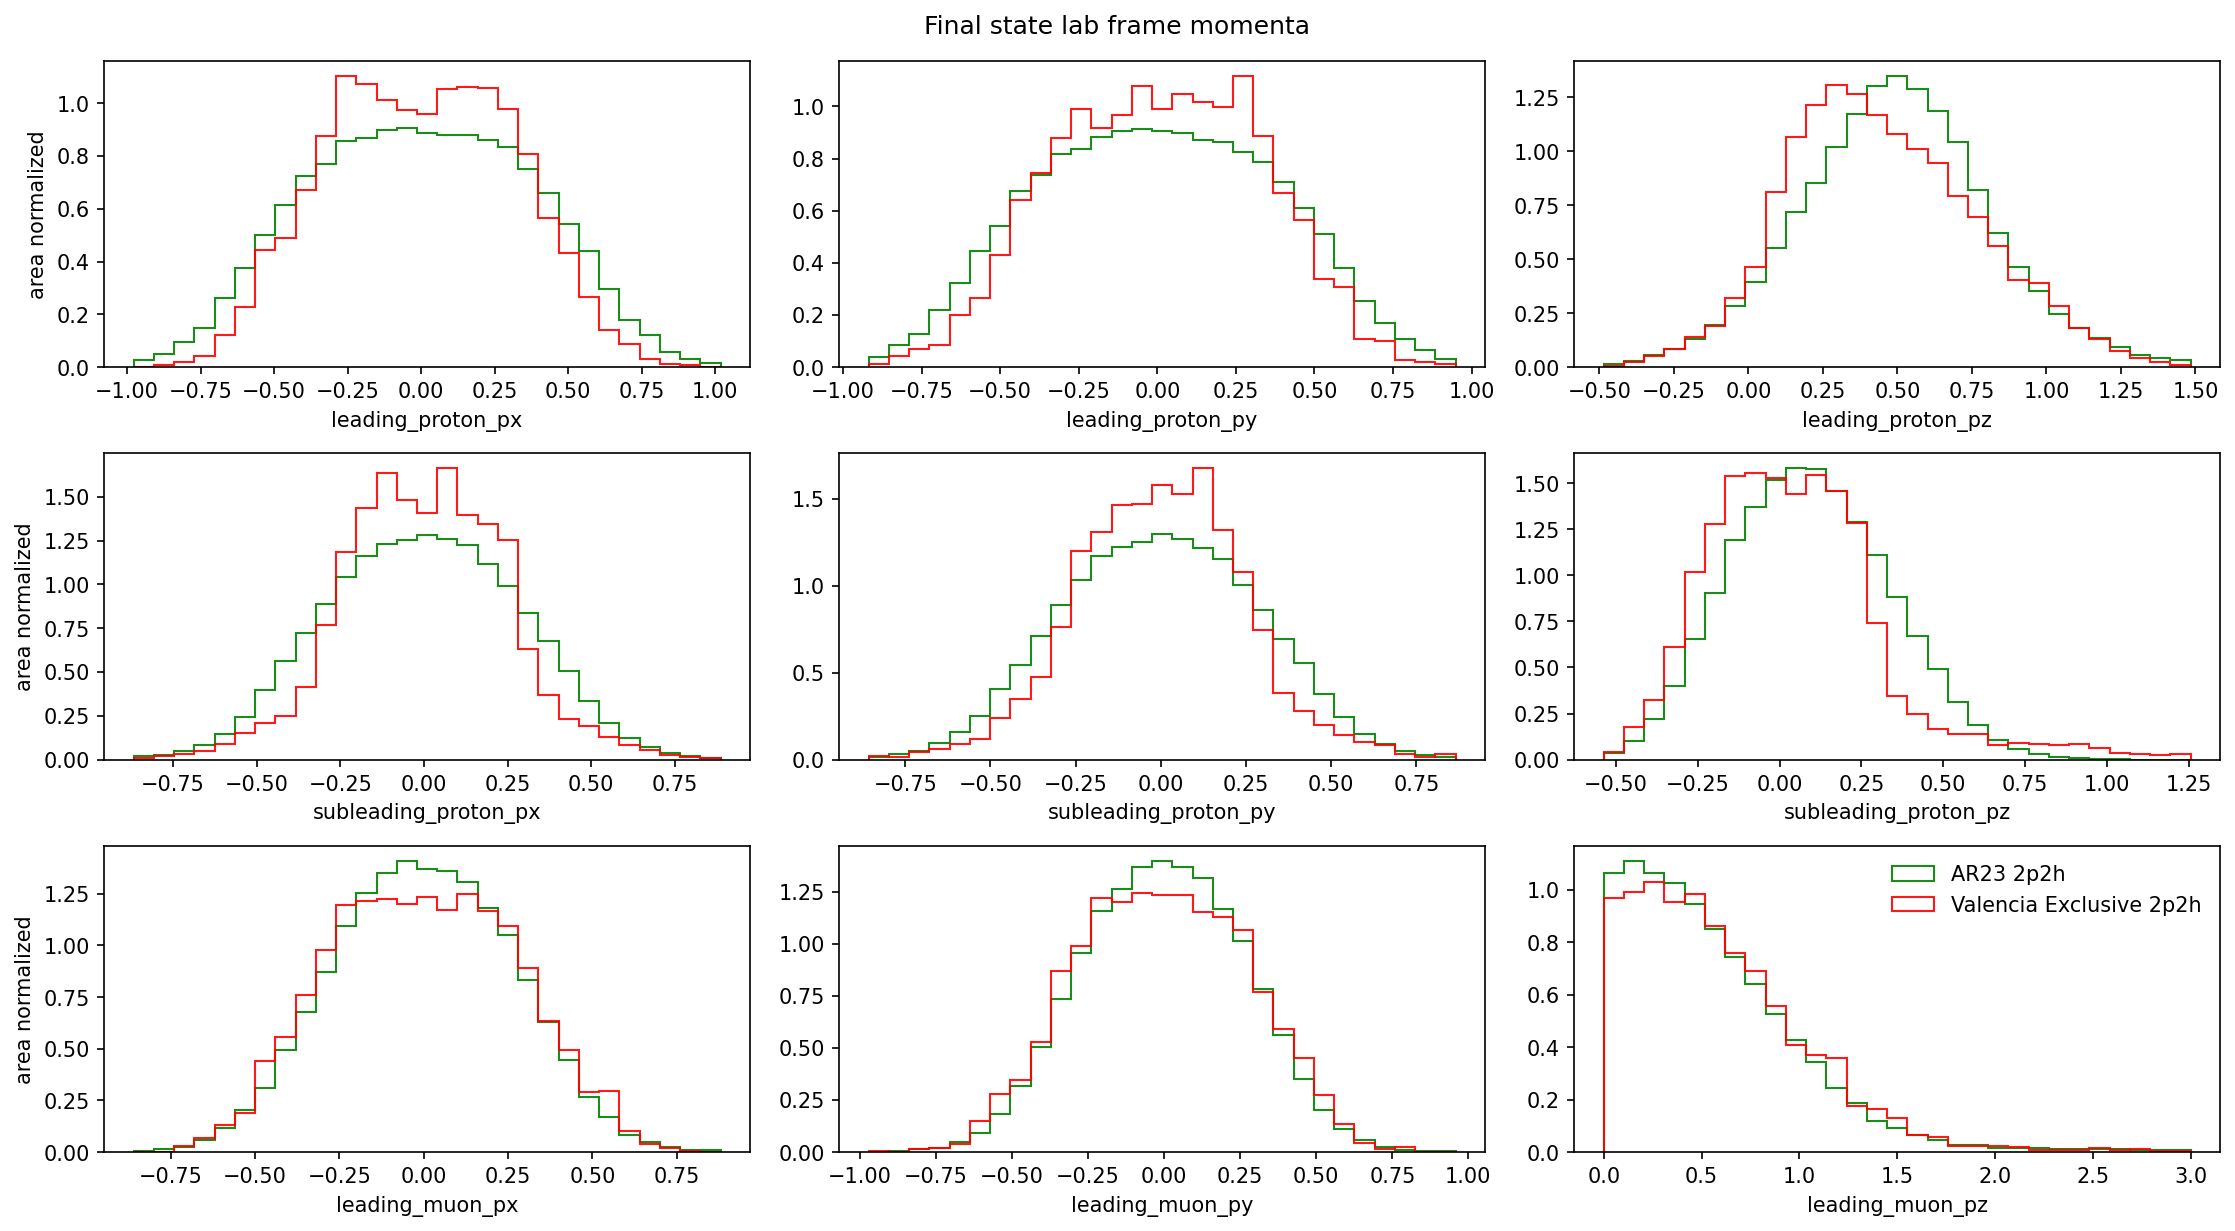

In [25]:
# plot lab frame momenta
fig, axs = plt.subplots(nrows=3, ncols=3,figsize=(15,8), dpi=150)
for i, ax in enumerate(axs.flat):

    var = drawing_variables[i]
    if i == 8:
        bins = np.linspace(0, 3, 30)
    else:
        bins = np.linspace(np.min([df_source[var].min(), df_target[var].min()]),np.max([df_source[var].max(), df_target[var].max()]),30)*0.7

    ax.hist(df_source[var], weights=np.ones(len(df_source)), color='green', alpha=0.9,histtype='step',bins=bins, label='AR23 2p2h', density=True)
    ax.hist(df_target[var], weights=df_target['weight'],     color='red', alpha=0.9,histtype='step',bins=bins, label='Valencia Exclusive 2p2h', density=True)
    # ax.hist(df_source[var], weights=new_weights,             color='blue', alpha=0.9, histtype='step',bins=bins, label='AR23 2p2h rw', linestyle='--', density=True)
    ax.set_xlabel(var)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    if i in [0, 3, 6]:
        ax.set_ylabel('area normalized')
    if i == 8:
        ax.legend(frameon=False)
plt.tight_layout()
plt.suptitle('Final state lab frame momenta', y = 1.02)
plt.show()

In [26]:
# convert lab frame momenta to reaction plane frame
input_features = reaction_frame_2p2h_momenta(
    nucleon1_px = df_source['leading_proton_px'], nucleon1_py = df_source['leading_proton_py'], nucleon1_pz = df_source['leading_proton_pz'],
    nucleon2_px = df_source['subleading_proton_px'], nucleon2_py = df_source['subleading_proton_py'], nucleon2_pz = df_source['subleading_proton_pz'],
    lepton_px = df_source['leading_muon_px'], lepton_py = df_source['leading_muon_py'], lepton_pz = df_source['leading_muon_pz'],
)

# put them in place of arrays in dataframe
df_source[reweight_variables] = input_features
df_target[reweight_variables] = reaction_frame_2p2h_momenta(
    nucleon1_px = df_target['leading_proton_px'], nucleon1_py = df_target['leading_proton_py'], nucleon1_pz = df_target['leading_proton_pz'],
    nucleon2_px = df_target['subleading_proton_px'], nucleon2_py = df_target['subleading_proton_py'], nucleon2_pz = df_target['subleading_proton_pz'],
    lepton_px = df_target['leading_muon_px'], lepton_py = df_target['leading_muon_py'], lepton_pz = df_target['leading_muon_pz'],
)
df_source['leading_muon_px'] = 0.0
df_target['leading_muon_px'] = 0.0

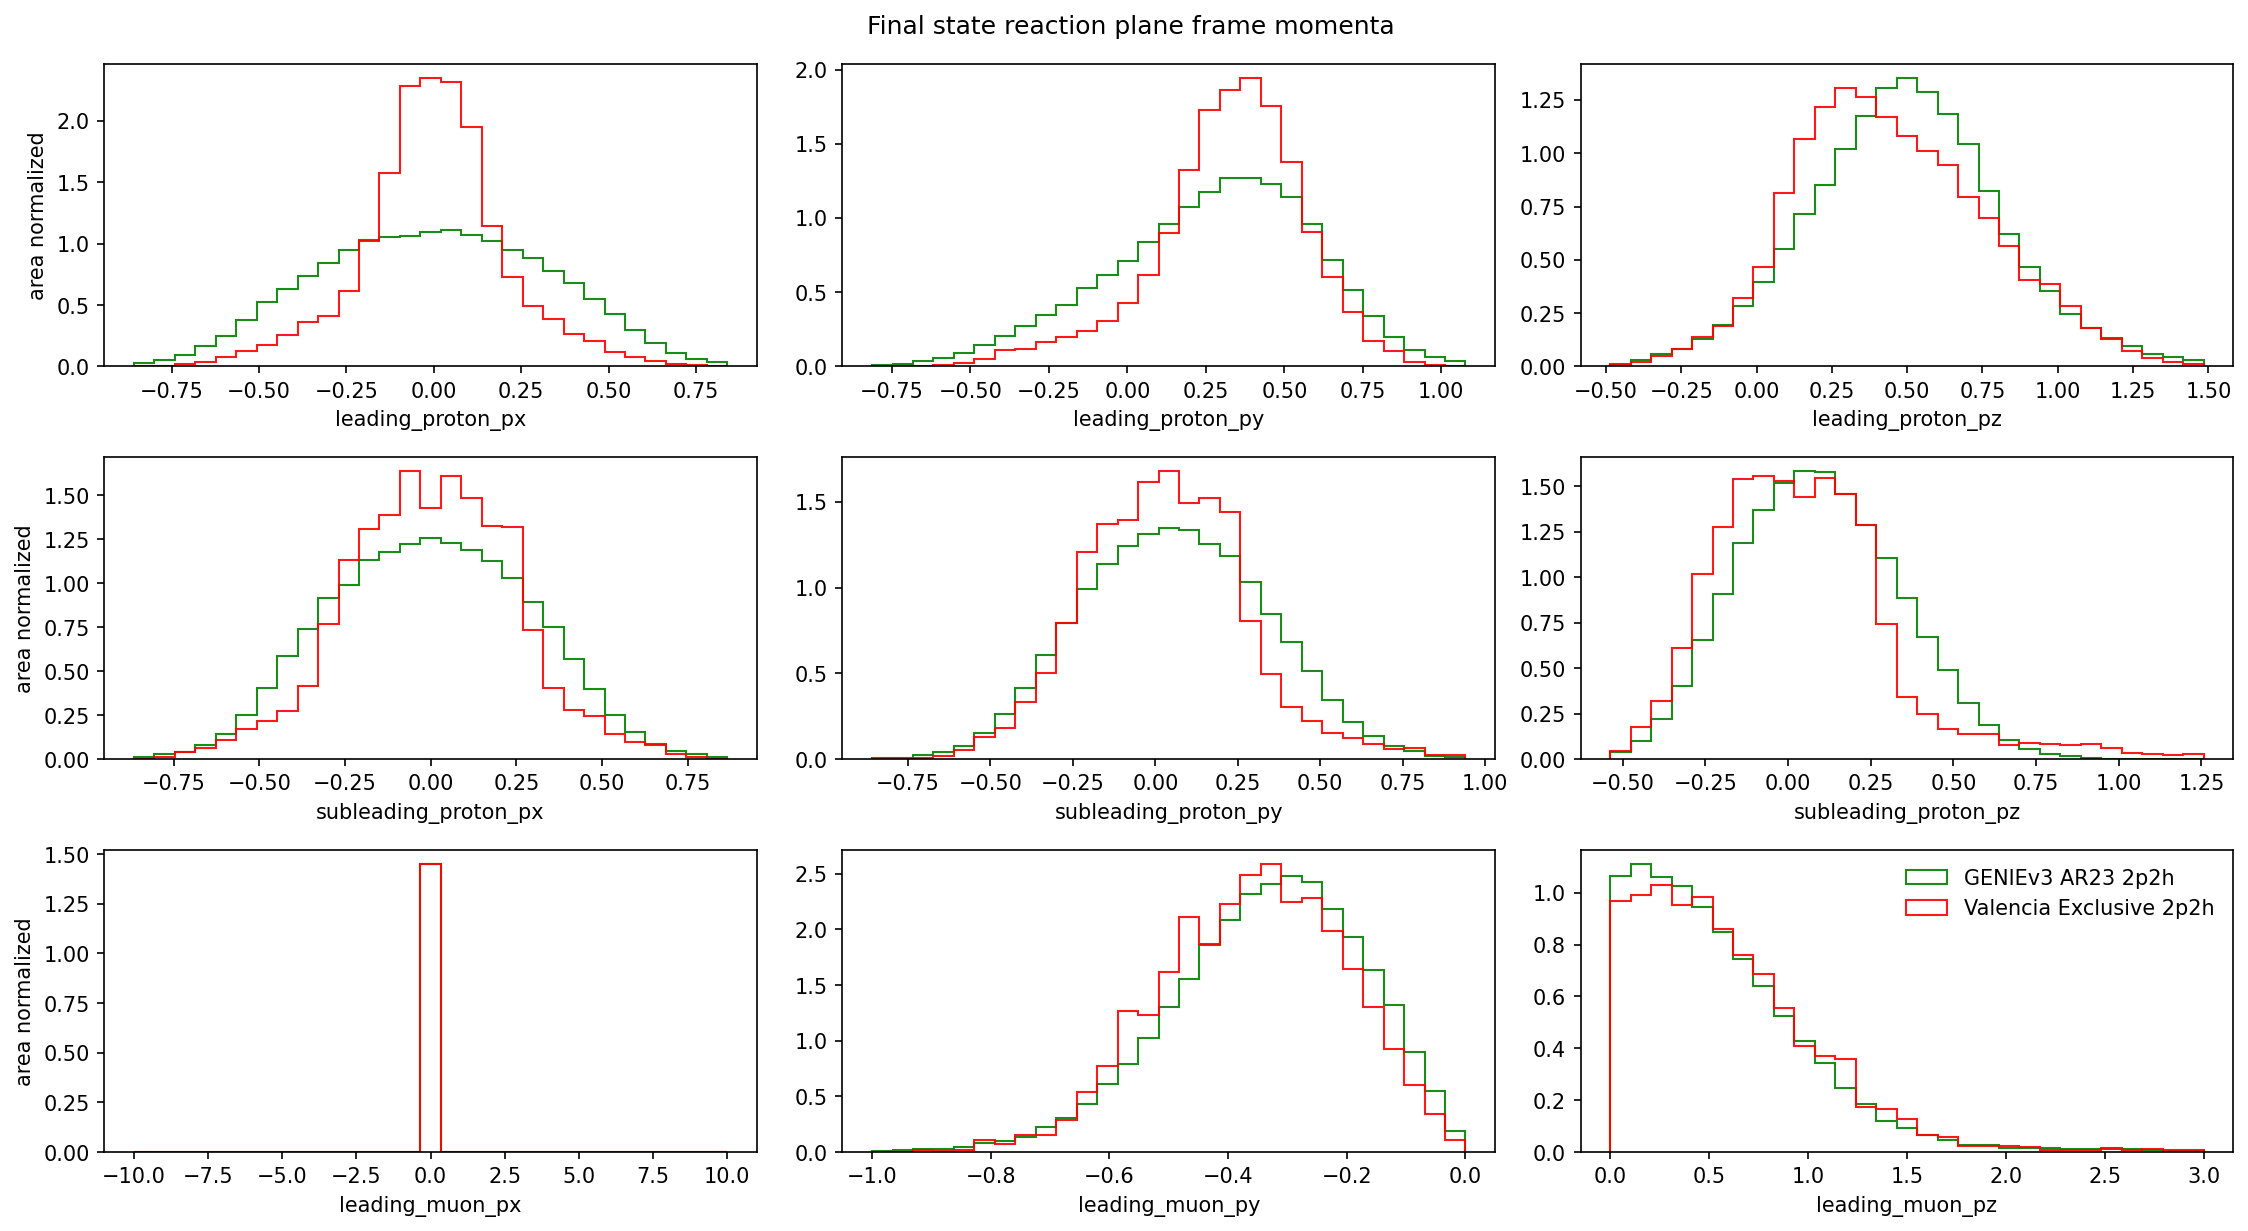

In [27]:
# plot reaction plane frame momenta
fig, axs = plt.subplots(nrows=3, ncols=3,figsize=(15,8), dpi=150)
for i, ax in enumerate(axs.flat):

    var = drawing_variables[i]
    if var == 'leading_muon_px':
        bins = np.linspace(-10, 10, 30)
    elif var == 'leading_muon_py':
        bins = np.linspace(-1, 0, 30)
    elif var == 'leading_muon_pz':
        bins = np.linspace(0, 3, 30)
    else:
        bins = np.linspace(np.min([df_source[var].min(), df_target[var].min()]),np.max([df_source[var].max(), df_target[var].max()]),30)*0.7

    ax.hist(df_source[var], weights=np.ones(len(df_source)), color='green', alpha=0.9,histtype='step',bins=bins, label='GENIEv3 AR23 2p2h', density=True)
    ax.hist(df_target[var], weights=df_target['weight'],     color='red', alpha=0.9,histtype='step',bins=bins, label='Valencia Exclusive 2p2h', density=True)
    # ax.hist(df_source[var], weights=new_weights,             color='blue', alpha=0.9, histtype='step',bins=bins, label='AR23 2p2h rw', linestyle='--', density=True)
    ax.set_xlabel(var)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    if i in [0, 3, 6]:
        ax.set_ylabel('area normalized')
    if i == 8:
        ax.legend(frameon=False)
plt.tight_layout()
plt.suptitle('Final state reaction plane frame momenta', y = 1.02)
plt.show()


There are 0 out of 80946 entries with w > 20: []
There are 13 out of 80946 entries with w > 20: [2.33e+12, 2.88e+03, 304, 140, ..., 1.39e+06, 7.88e+03, 2.46e+03, 6.18e+15]
There are 18 out of 80946 entries with w > 20: [4.66e+12, 5.76e+03, 607, 278, 40.7, ..., 4.93e+03, 1.24e+16, 24.4, 20.7]
There are 23 out of 80946 entries with w > 20: [6.99e+12, 8.64e+03, 910, 417, 60.5, ..., 21.5, 1.85e+16, 36.1, 26.4, 30.6]
There are 25 out of 80946 entries with w > 20: [9.32e+12, 1.15e+04, 1.21e+03, 556, 80.3, ..., 2.47e+16, 47.8, 34.8, 23.7, 40.5]


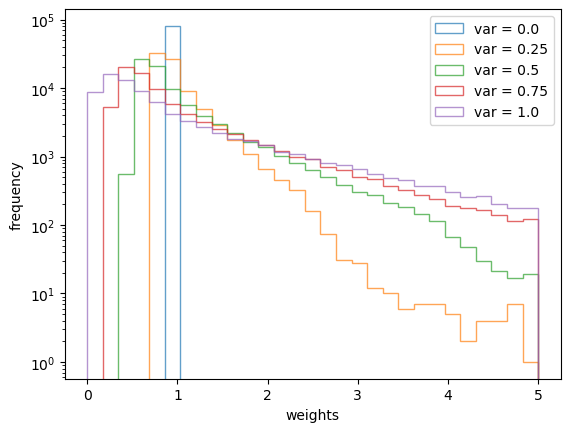

In [28]:
# test variation from dumped output
plt.figure()

for i in [0, 1,2,3,4]:
    var = variations[i]
    new_weights = df_event['tweak_responses_ValenciaExc2p2hReweighter_test_DialValencia'][:,i][mask]
    plt.hist(new_weights, bins=np.linspace(0,5,30), label=f'var = {var}', histtype='step',alpha=0.7)
    print(f'There are {len(new_weights[new_weights>20])} out of {len(new_weights)} entries with w > 20:',new_weights[new_weights>20])

plt.xlabel('weights')
plt.ylabel('frequency')
plt.yscale('log')
plt.legend()
plt.show()

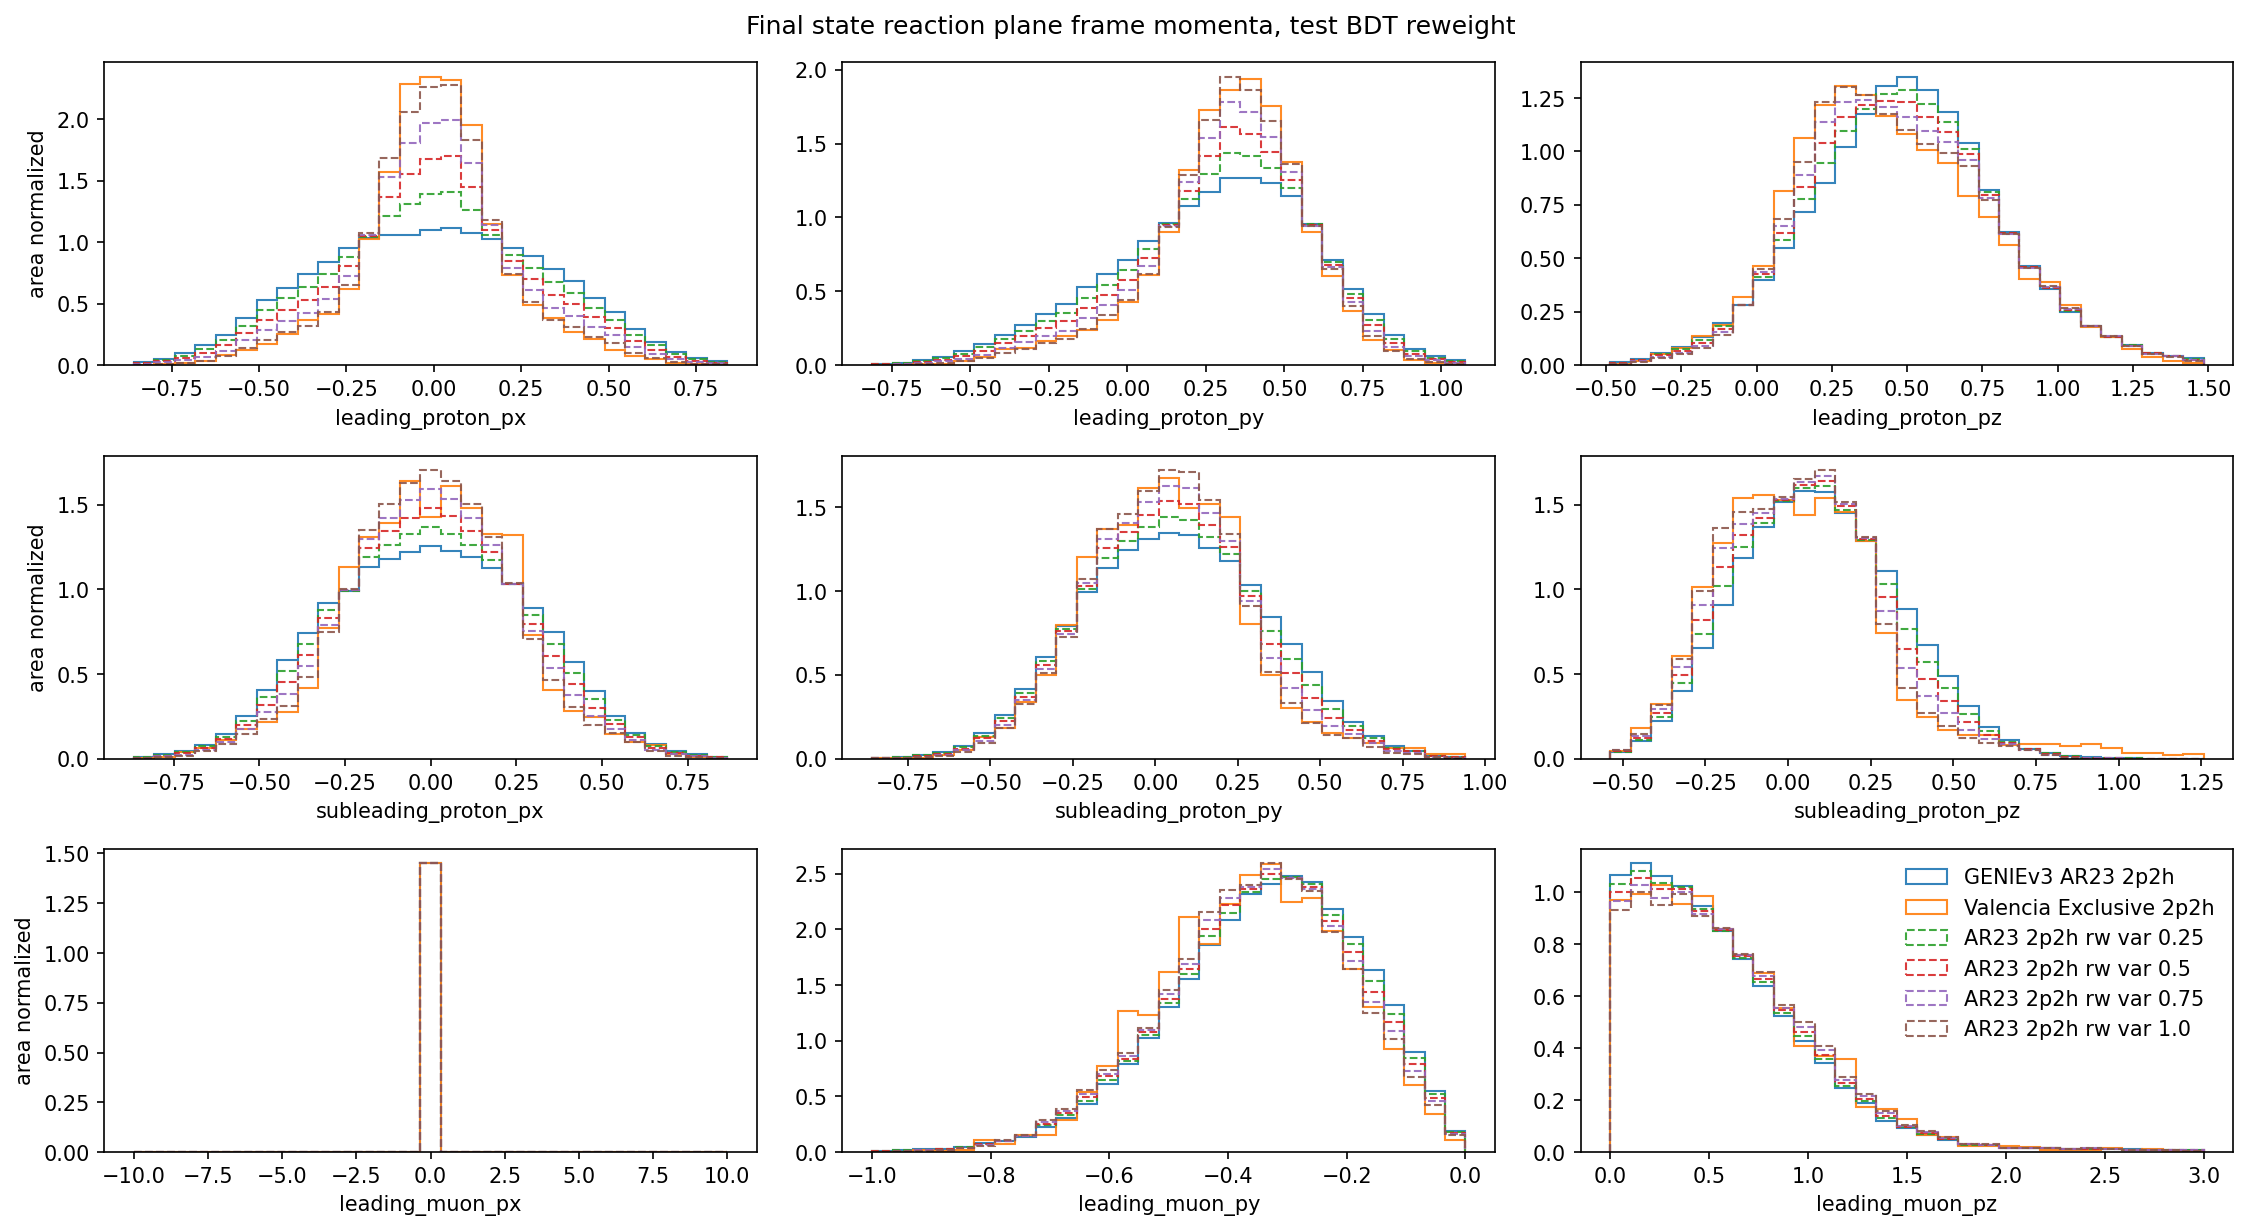

In [29]:
# plot reaction plane frame momenta
fig, axs = plt.subplots(nrows=3, ncols=3,figsize=(15,8), dpi=150)
for i, ax in enumerate(axs.flat):

    var = drawing_variables[i]
    if var == 'leading_muon_px':
        bins = np.linspace(-10, 10, 30)
    elif var == 'leading_muon_py':
        bins = np.linspace(-1, 0, 30)
    elif var == 'leading_muon_pz':
        bins = np.linspace(0, 3, 30)
    else:
        bins = np.linspace(np.min([df_source[var].min(), df_target[var].min()]),np.max([df_source[var].max(), df_target[var].max()]),30)*0.7

    ax.hist(df_source[var], weights=np.ones(len(df_source)), alpha=0.9,histtype='step',bins=bins, label='GENIEv3 AR23 2p2h', density=True)
    ax.hist(df_target[var], weights=df_target['weight'], alpha=0.9,histtype='step',bins=bins, label='Valencia Exclusive 2p2h', density=True)
    # ax.hist(df_source[var], weights=new_weights,             color='blue', alpha=0.9, histtype='step',bins=bins, label='AR23 2p2h nusystematics rw', linestyle='--', density=True)
    for j in [1,2,3,4]:
        new_weights = np.array(df_event['tweak_responses_ValenciaExc2p2hReweighter_test_DialValencia'][:,j][mask])
        new_weights[new_weights > 20] = 0
        ax.hist(df_source[var], weights=new_weights, alpha=0.9, histtype='step',bins=bins, label=f'AR23 2p2h rw var {variations[j]}', linestyle='--', density=True)

    ax.set_xlabel(var)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    if i in [0, 3, 6]:
        ax.set_ylabel('area normalized')
    if i == 8:
        ax.legend(frameon=False)
plt.tight_layout()
plt.suptitle('Final state reaction plane frame momenta, test BDT reweight', y = 1.02)
plt.show()

## Validate pn out-going states

In [30]:
# reweight variables (the ORDER matters) and drawing variables
reweight_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'leading_muon_py', 'leading_muon_pz',
]

drawing_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'leading_muon_px','leading_muon_py', 'leading_muon_pz',
]


In [31]:
# extract pp states 2p2h prefsi kinematics
vertp_pdg = df_event['fsi_pdgs']
vertp_px = df_event['fsi_pxs']
vertp_py = df_event['fsi_pys']
vertp_pz = df_event['fsi_pzs']
Enu_true = df_event['Enu_true']

pdg_to_mass = {2212:0.93827, 2112:0.93957}
vertp_mass = np.vectorize(lambda x: pdg_to_mass.get(x, 'unknown'))(vertp_pdg)
vertp_E = np.sqrt(vertp_px**2 + vertp_py**2 + vertp_pz**2 + vertp_mass**2)
vertp_KE = vertp_E - vertp_mass

order = ak.argsort(vertp_KE, axis=1, ascending=False)
primary_pdg = vertp_pdg[order][:,0]
spectator_pdg = vertp_pdg[order][:,1]

# mask = (primary_pdg == 2212) & (spectator_pdg == 2212) # pp final states
mask = ~ ((primary_pdg == 2212) & (spectator_pdg == 2212)) # pn final states

# # prepare SuSAv2 2p2h dataframe
df_source = pd.DataFrame() 
df_source['init_neutrino_E'] = Enu_true[mask]
df_source['leading_muon_px'] = df_event['lep_px'][mask]
df_source['leading_muon_py'] = df_event['lep_py'][mask]
df_source['leading_muon_pz'] = df_event['lep_pz'][mask]
 
 
# pn channel proton, neutron kinematics:
leading_i = ak.argmax(vertp_KE, axis=1, keepdims=True)
subleading_i = ak.argmin(vertp_KE, axis=1, keepdims=True)

df_source['leading_proton_px'] = ak.firsts(vertp_px[vertp_pdg == 2212])[mask]
df_source['leading_proton_py'] = ak.firsts(vertp_py[vertp_pdg == 2212])[mask]
df_source['leading_proton_pz'] = ak.firsts(vertp_pz[vertp_pdg == 2212])[mask]
df_source['leading_neutron_px'] = ak.firsts(vertp_px[vertp_pdg == 2112])[mask]
df_source['leading_neutron_py'] = ak.firsts(vertp_py[vertp_pdg == 2112])[mask]
df_source['leading_neutron_pz'] = ak.firsts(vertp_pz[vertp_pdg == 2112])[mask]


# convert to reaction plane frame
input_features = reaction_frame_2p2h_momenta(
    nucleon1_px = df_source['leading_proton_px'], nucleon1_py = df_source['leading_proton_py'], nucleon1_pz = df_source['leading_proton_pz'],
    nucleon2_px = df_source['leading_neutron_px'], nucleon2_py = df_source['leading_neutron_py'], nucleon2_pz = df_source['leading_neutron_pz'],
    lepton_px = df_source['leading_muon_px'], lepton_py = df_source['leading_muon_py'], lepton_pz = df_source['leading_muon_pz'],
)

# put them in place of arrays in dataframe
df_source[reweight_variables] = input_features

In [32]:
# read muon, proton, neutron kinematics from pre-processed csv file (this one already in reaction plane frame)
df_target = pd.read_csv('/exp/icarus/data/users/zihaolin/MC_outputs/bdtreweighters_json/bdt_train_2p2h_csv/newValencia_2p2h_pn_states.csv')
print("target csv columns:", df_target.columns)

target csv columns: Index(['leading_muon_px', 'leading_muon_py', 'leading_muon_pz',
       'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
       'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
       'weight_pn', 'weight_np', 'init_neutrino_E', 'weight'],
      dtype='object')


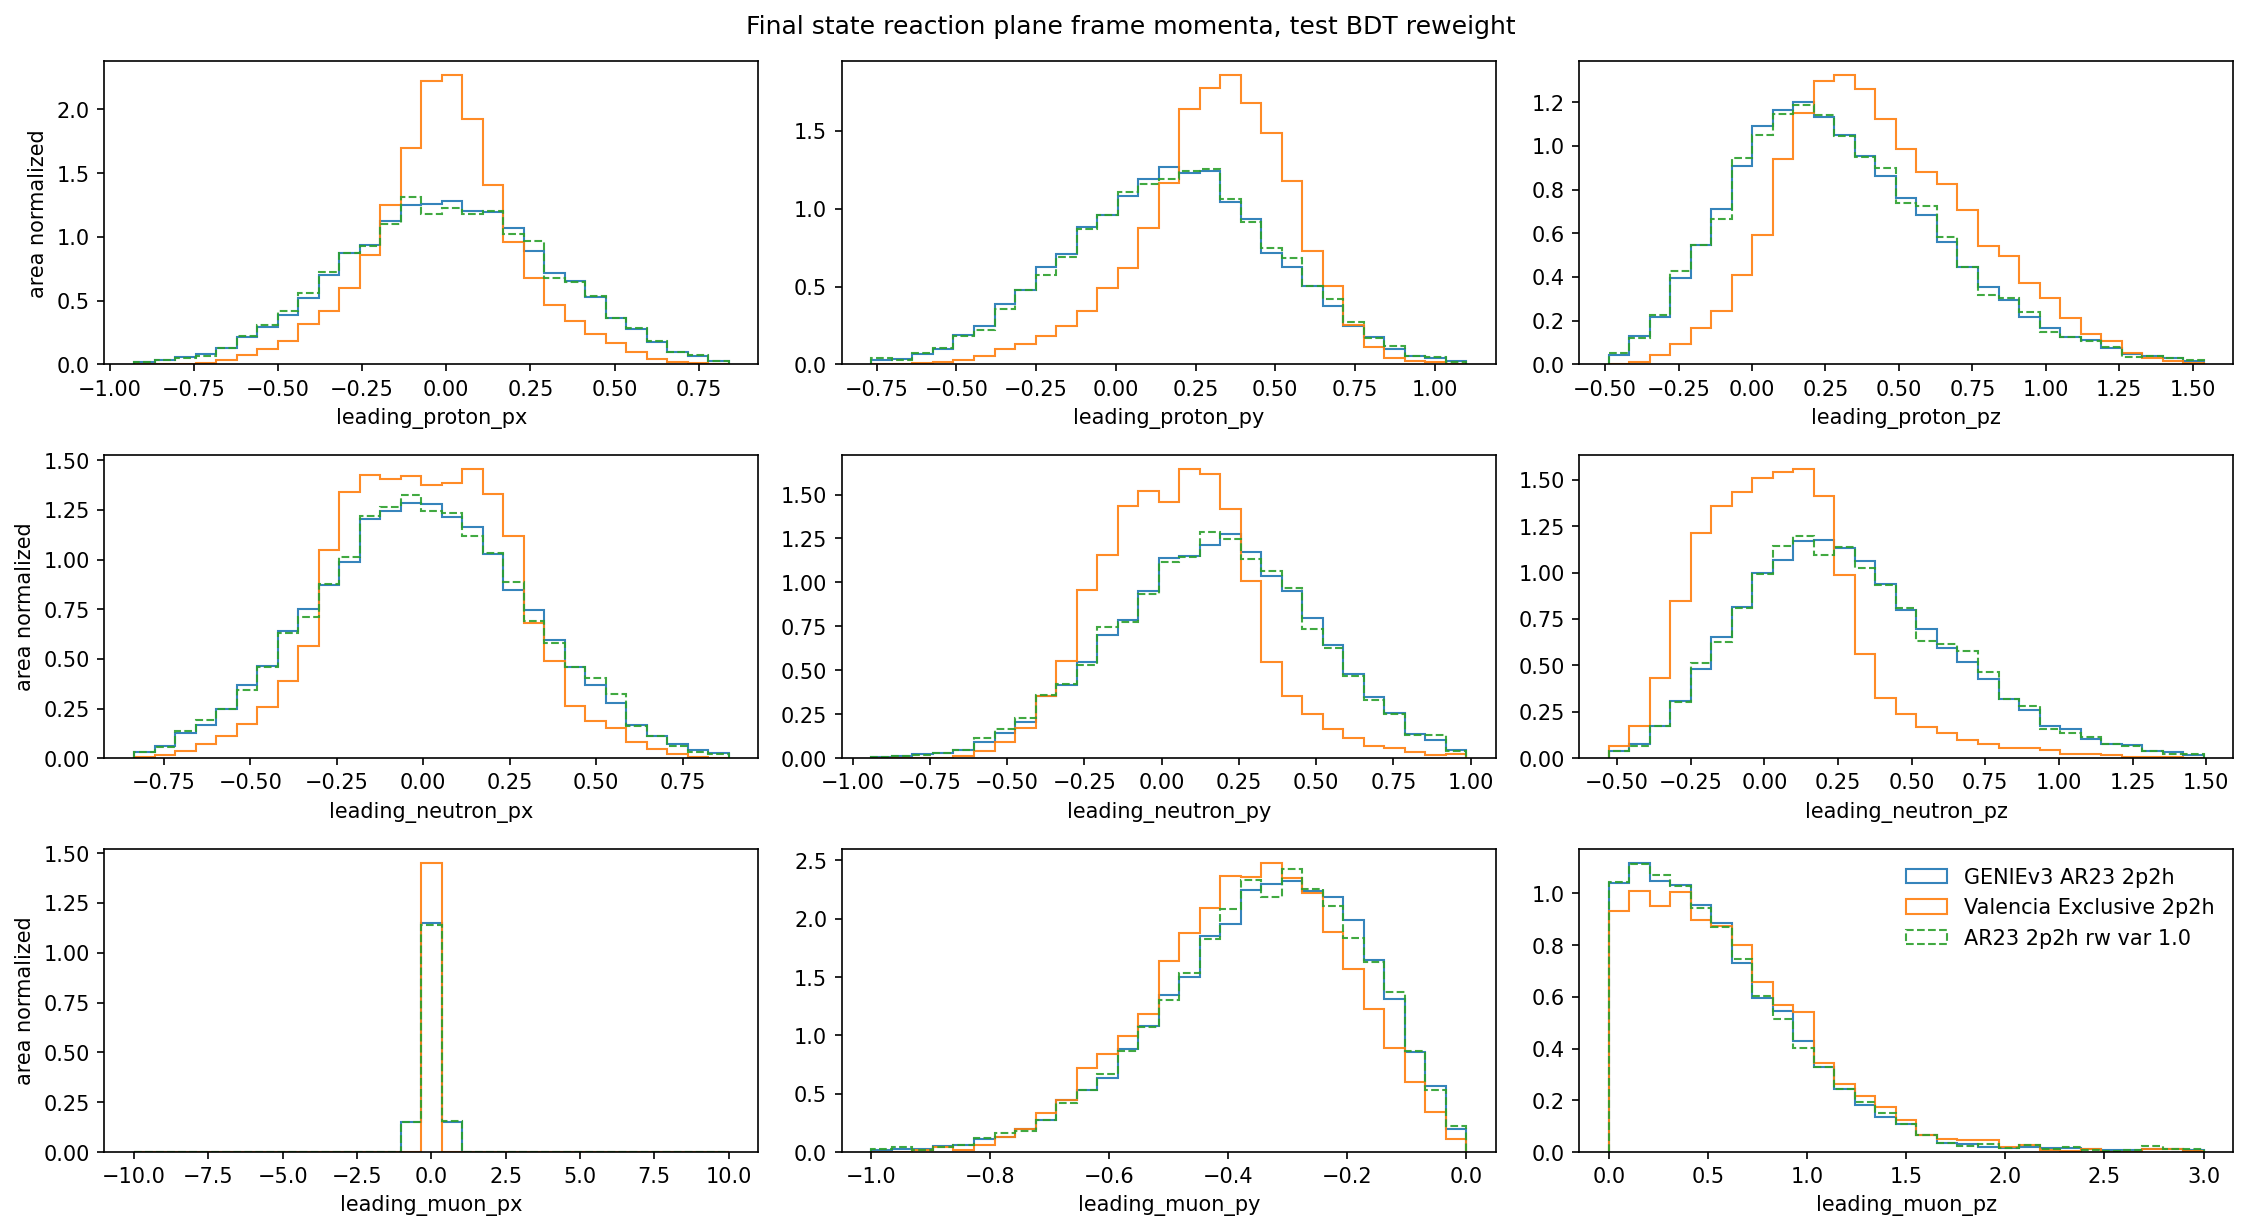

In [39]:
# plot reaction plane frame momenta
fig, axs = plt.subplots(nrows=3, ncols=3,figsize=(15,8), dpi=150)
for i, ax in enumerate(axs.flat):

    var = drawing_variables[i]
    if var == 'leading_muon_px':
        bins = np.linspace(-10, 10, 30)
    elif var == 'leading_muon_py':
        bins = np.linspace(-1, 0, 30)
    elif var == 'leading_muon_pz':
        bins = np.linspace(0, 3, 30)
    else:
        bins = np.linspace(np.min([df_source[var].min(), df_target[var].min()]),np.max([df_source[var].max(), df_target[var].max()]),30)*0.7

    ax.hist(df_source[var], weights=np.ones(len(df_source)), alpha=0.9,histtype='step',bins=bins, label='GENIEv3 AR23 2p2h', density=True)
    ax.hist(df_target[var], weights=df_target['weight'], alpha=0.9,histtype='step',bins=bins, label='Valencia Exclusive 2p2h', density=True)
    # ax.hist(df_source[var], weights=new_weights,             color='blue', alpha=0.9, histtype='step',bins=bins, label='AR23 2p2h nusystematics rw', linestyle='--', density=True)
    # for j in [1,2,3,4]:
    for j in [4]:
        new_weights = np.array(df_event['tweak_responses_ValenciaExc2p2hReweighter_test_DialValencia'][:,j][mask])
        new_weights[new_weights > 20] = 0
        ax.hist(df_source[var], weights=new_weights, alpha=0.9, histtype='step',bins=bins, label=f'AR23 2p2h rw var {variations[j]}', linestyle='--', density=True)

    ax.set_xlabel(var)
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    if i in [0, 3, 6]:
        ax.set_ylabel('area normalized')
    if i == 8:
        ax.legend(frameon=False)
plt.tight_layout()
plt.suptitle('Final state reaction plane frame momenta, test BDT reweight', y = 1.02)
plt.show()

## Validate scale factor
BDT reweight is a shape only reweight. It has no control of total weights magnitude.

To preserve event rate, number of events / sum(weights) should be close to 1. 

In [37]:
weights_pp = []
weights_pn = []
for seed in range(300,330):
    with uproot.open(f"/exp/icarus/data/users/zihaolin/MC_outputs/GENIE_v3/NuSystTrees/NuSystTree_ICARUS_BNB_FHC_numu_Ca12_CCMEC_{seed}.root") as f:
        
        df_event = f["events"].arrays(library="ak")[['fsi_pdgs','tweak_responses_ValenciaExc2p2hReweighter_test_DialValencia']]
        mask_pp = (df_event['fsi_pdgs'][:,0] == 2212) & (df_event['fsi_pdgs'][:,1] == 2212)
        mask_pn = ~ mask_pp
        weights = np.array(df_event['tweak_responses_ValenciaExc2p2hReweighter_test_DialValencia'][:,4]) # dial = 1.0 is fully reweighted to Valencia exclusive
        print(f'pp + pn: there are {len(weights[weights>20])} out of {len(weights)} entries with w > 20, will set to 0.')
        weights[weights > 20] = 0.0
        print(f'pp: n_events = {np.sum(mask_pp)}, sum(w) = {np.sum(weights[mask_pp])}, ratio = {np.sum(mask_pp)/np.sum(weights[mask_pp])}')        
        print(f'pn: n_events = {np.sum(mask_pn)}, sum(w) = {np.sum(weights[mask_pn])}, ratio = {np.sum(mask_pn)/np.sum(weights[mask_pn])}')
        
        weights_pp.append(weights[mask_pp])
        weights_pn.append(weights[mask_pn])

weights_pp = np.concatenate(weights_pp)
weights_pn = np.concatenate(weights_pn)

pp + pn: there are 23 out of 100000 entries with w > 20, will set to 0.
pp: n_events = 80931, sum(w) = 81194.57996862853, ratio = 0.9967537245869075
pn: n_events = 19069, sum(w) = 18601.868667628893, ratio = 1.0251120648531409
pp + pn: there are 33 out of 100000 entries with w > 20, will set to 0.
pp: n_events = 80993, sum(w) = 80658.60873043032, ratio = 1.0041457604443347
pn: n_events = 19007, sum(w) = 18851.882341479668, ratio = 1.0082282318396942
pp + pn: there are 32 out of 100000 entries with w > 20, will set to 0.
pp: n_events = 80934, sum(w) = 80933.83425459848, ratio = 1.0000020479123848
pn: n_events = 19066, sum(w) = 18848.683443030342, ratio = 1.0115295350800755
pp + pn: there are 40 out of 100000 entries with w > 20, will set to 0.
pp: n_events = 80822, sum(w) = 80358.71245617545, ratio = 1.0057652434896491
pn: n_events = 19178, sum(w) = 19232.98952627225, ratio = 0.9971408747351974
pp + pn: there are 27 out of 100000 entries with w > 20, will set to 0.
pp: n_events = 80948,

In [38]:
ratio_pp = len(weights_pp)/np.sum(weights_pp)
ratio_pn = len(weights_pn)/np.sum(weights_pn)
print(f'pp: len(w) = {len(weights_pp)}, sum(w) = {np.sum(weights_pp)}, ratio = {ratio_pp}')
print(f'pn: len(w) = {len(weights_pn)}, sum(w) = {np.sum(weights_pn)}, ratio = {ratio_pn}')
print(f'pp + pn total number of events: {len(weights_pp)+len(weights_pn)}')

pp: len(w) = 2427547, sum(w) = 2420034.6521722716, ratio = 1.0031042315121337
pn: len(w) = 572453, sum(w) = 568007.8255902403, ratio = 1.0078259034638133
pp + pn total number of events: 3000000
